In [1]:
import numpy as np
import gzip
import os


def load_mnist(path, kind='train'):
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')
    
    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)
    
    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 784)
    
    return images, labels


class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.01
        self.b2 = np.zeros(output_dim)
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def cross_entropy_loss(self, logits, labels):
        batch_size = logits.shape[0]
        probs = self.softmax(logits)
        log_probs = -np.log(probs[range(batch_size), labels] + 1e-9)
        return np.mean(log_probs)
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2
    
    def backward(self, X, y, learning_rate=0.01):
        batch_size = X.shape[0]
        
        probs = self.softmax(self.z2)
        dz2 = probs.copy()
        dz2[range(batch_size), y] -= 1
        dz2 /= batch_size
        
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0)
        
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * (self.z1 > 0).astype(float)
        
        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0)
        
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2


def train(model, X_train, y_train, epochs=10, batch_size=64, learning_rate=0.01):
    n_samples = X_train.shape[0]
    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total = 0
        
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            logits = model.forward(X_batch)
            loss = model.cross_entropy_loss(logits, y_batch)
            
            model.backward(X_batch, y_batch, learning_rate)
            
            total_loss += loss * len(y_batch)
            predictions = np.argmax(logits, axis=1)
            total += len(y_batch)
            correct += np.sum(predictions == y_batch)
        
        avg_loss = total_loss / n_samples
        accuracy = 100.0 * correct / total
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')


def test(model, X_test, y_test):
    logits = model.forward(X_test)
    predictions = np.argmax(logits, axis=1)
    accuracy = 100.0 * np.sum(predictions == y_test) / len(y_test)
    print(f'测试准确率: {accuracy:.2f}%')


if __name__ == '__main__':
    import urllib.request
    import os
    
    data_dir = './data'
    os.makedirs(data_dir, exist_ok=True)
    
    base_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/'
    
    files = [
        'train-images-idx3-ubyte.gz',
        'train-labels-idx1-ubyte.gz',
        't10k-images-idx3-ubyte.gz',
        't10k-labels-idx1-ubyte.gz'
    ]
    
    for f in files:
        filepath = os.path.join(data_dir, f)
        if not os.path.exists(filepath):
            print(f'Downloading {f}...')
            urllib.request.urlretrieve(base_url + f, filepath)
    
    print('正在加载数据...')
    X_train, y_train = load_mnist(data_dir, kind='train')
    X_test, y_test = load_mnist(data_dir, kind='t10k')
    
    X_train = X_train.astype(np.float64) / 255.0
    X_test = X_test.astype(np.float64) / 255.0
    
    mean = np.mean(X_train)
    std = np.std(X_train)
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std
    
    input_dim = 28 * 28
    hidden_dim = 128
    output_dim = 10
    
    model = MLP(input_dim, hidden_dim, output_dim)
    
    print('训练开始...')
    train(model, X_train, y_train, epochs=10, batch_size=64, learning_rate=0.1)
    
    print('测试中...')
    test(model, X_test, y_test)

正在加载数据...
训练开始...
Epoch [1/10], Loss: 0.5287, Accuracy: 80.64%
Epoch [2/10], Loss: 0.3793, Accuracy: 86.06%
Epoch [3/10], Loss: 0.3387, Accuracy: 87.60%
Epoch [4/10], Loss: 0.3133, Accuracy: 88.42%
Epoch [5/10], Loss: 0.2944, Accuracy: 89.13%
Epoch [6/10], Loss: 0.2793, Accuracy: 89.53%
Epoch [7/10], Loss: 0.2651, Accuracy: 90.19%
Epoch [8/10], Loss: 0.2548, Accuracy: 90.50%
Epoch [9/10], Loss: 0.2412, Accuracy: 91.03%
Epoch [10/10], Loss: 0.2329, Accuracy: 91.29%
测试中...
测试准确率: 88.59%


Loading data...
使用 3000 个训练样本, 5000 个验证样本

===== 实验1: 无正则化 =====
Epoch [5/50], Loss: 0.4815, Acc: 81.97%, Val Loss: 0.5758, Val Acc: 77.42%
Epoch [10/50], Loss: 0.3573, Acc: 86.57%, Val Loss: 0.4858, Val Acc: 82.78%
Epoch [15/50], Loss: 0.2553, Acc: 91.43%, Val Loss: 0.4703, Val Acc: 83.48%
Epoch [20/50], Loss: 0.1959, Acc: 93.70%, Val Loss: 0.4701, Val Acc: 84.06%
Epoch [25/50], Loss: 0.1573, Acc: 94.90%, Val Loss: 0.5141, Val Acc: 82.68%
Epoch [30/50], Loss: 0.1154, Acc: 96.07%, Val Loss: 0.5059, Val Acc: 84.86%
Epoch [35/50], Loss: 0.0778, Acc: 97.87%, Val Loss: 0.6624, Val Acc: 80.82%
Epoch [40/50], Loss: 0.0771, Acc: 98.00%, Val Loss: 0.5858, Val Acc: 83.30%
Epoch [45/50], Loss: 0.0425, Acc: 99.07%, Val Loss: 0.5925, Val Acc: 83.92%
Epoch [50/50], Loss: 0.0296, Acc: 99.63%, Val Loss: 0.6039, Val Acc: 84.54%
Test Accuracy: 83.44%

===== 实验2: 权重衰减 =====
Epoch [5/50], Loss: 0.4831, Acc: 81.73%, Val Loss: 0.5747, Val Acc: 77.22%
Epoch [10/50], Loss: 0.3614, Acc: 86.60%, Val Loss: 0.48

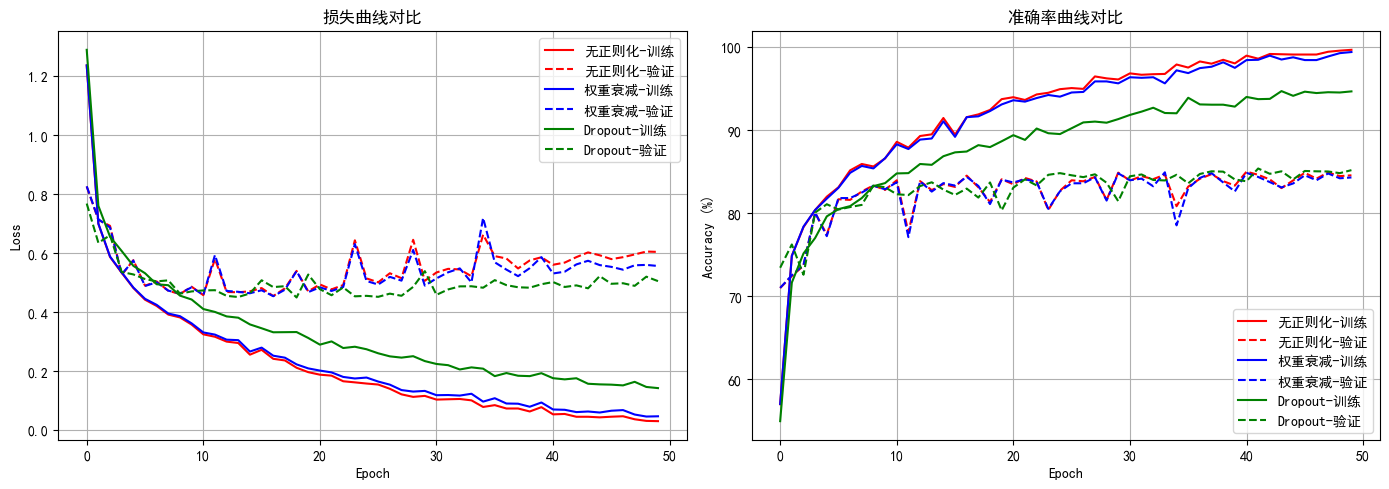

In [2]:
import numpy as np
import gzip
import os
import urllib.request
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def load_mnist(path, kind='train'):
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')
    
    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)
    
    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 784)
    
    return images, labels


def dropout_layer(X, dropout):
    mask = np.random.rand(*X.shape) > dropout
    return (X * mask) / (1.0 - dropout), mask


class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.0, weight_decay=0.0):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.dropout = dropout
        self.weight_decay = weight_decay
        self.is_training = True
        
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.01
        self.b2 = np.zeros(output_dim)
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def cross_entropy_loss(self, logits, labels):
        batch_size = logits.shape[0]
        probs = self.softmax(logits)
        log_probs = -np.log(probs[range(batch_size), labels] + 1e-9)
        return np.mean(log_probs)
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        
        if self.is_training and self.dropout > 0:
            self.a1, self.dropout_mask = dropout_layer(self.a1, self.dropout)
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2
    
    def backward(self, X, y, learning_rate=0.01):
        batch_size = X.shape[0]
        
        probs = self.softmax(self.z2)
        dz2 = probs.copy()
        dz2[range(batch_size), y] -= 1
        dz2 /= batch_size
        
        dW2 = np.dot(self.a1.T, dz2) + self.weight_decay * self.W2
        db2 = np.sum(dz2, axis=0)
        
        da1 = np.dot(dz2, self.W2.T)
        
        if self.is_training and self.dropout > 0:
            da1 = (da1 * self.dropout_mask) / (1.0 - self.dropout)
        
        dz1 = da1 * (self.z1 > 0).astype(float)
        
        dW1 = np.dot(X.T, dz1) + self.weight_decay * self.W1
        db1 = np.sum(dz1, axis=0)
        
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2


def train(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=64, learning_rate=0.01):
    n_samples = X_train.shape[0]
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        model.is_training = True
        total_loss = 0.0
        correct = 0
        total = 0
        
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            logits = model.forward(X_batch)
            loss = model.cross_entropy_loss(logits, y_batch)
            
            model.backward(X_batch, y_batch, learning_rate)
            
            total_loss += loss * len(y_batch)
            predictions = np.argmax(logits, axis=1)
            total += len(y_batch)
            correct += np.sum(predictions == y_batch)
        
        avg_loss = total_loss / n_samples
        accuracy = 100.0 * correct / total
        
        model.is_training = False
        val_logits = model.forward(X_val)
        val_loss = model.cross_entropy_loss(val_logits, y_val)
        val_predictions = np.argmax(val_logits, axis=1)
        val_accuracy = 100.0 * np.sum(val_predictions == y_val) / len(y_val)
        
        train_losses.append(avg_loss)
        val_losses.append(val_loss)
        train_accs.append(accuracy)
        val_accs.append(val_accuracy)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Acc: {accuracy:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
    
    return train_losses, val_losses, train_accs, val_accs


def test(model, X_test, y_test):
    model.is_training = False
    logits = model.forward(X_test)
    predictions = np.argmax(logits, axis=1)
    accuracy = 100.0 * np.sum(predictions == y_test) / len(y_test)
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy


if __name__ == '__main__':
    data_dir = './data'
    os.makedirs(data_dir, exist_ok=True)
    
    base_url = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/'
    files = [
        'train-images-idx3-ubyte.gz',
        'train-labels-idx1-ubyte.gz',
        't10k-images-idx3-ubyte.gz',
        't10k-labels-idx1-ubyte.gz'
    ]
    
    for f in files:
        filepath = os.path.join(data_dir, f)
        if not os.path.exists(filepath):
            print(f'Downloading {f}...')
            urllib.request.urlretrieve(base_url + f, filepath)
    
    print('Loading data...')
    X_train, y_train = load_mnist(data_dir, kind='train')
    X_test, y_test = load_mnist(data_dir, kind='t10k')
    
    X_train = X_train.astype(np.float64) / 255.0
    X_test = X_test.astype(np.float64) / 255.0
    
    mean = np.mean(X_train)
    std = np.std(X_train)
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std
    
    # 取少量训练数据加剧过拟合
    np.random.seed(42)
    indices = np.random.permutation(len(X_train))
    n_small = 3000
    X_train_small = X_train[indices[:n_small]]
    y_train_small = y_train[indices[:n_small]]
    X_val = X_train[indices[50000:55000]]
    y_val = y_train[indices[50000:55000]]
    
    print(f'使用 {n_small} 个训练样本, {len(X_val)} 个验证样本')
    
    input_dim = 28 * 28
    hidden_dim = 256
    output_dim = 10
    
    # 实验1: 无正则化
    print('\n===== 实验1: 无正则化 =====')
    np.random.seed(42)
    model1 = MLP(input_dim, hidden_dim, output_dim, dropout=0.0, weight_decay=0.0)
    train_loss1, val_loss1, train_acc1, val_acc1 = train(model1, X_train_small, y_train_small, X_val, y_val, epochs=50, batch_size=64, learning_rate=0.1)
    test(model1, X_test, y_test)
    
    # 实验2: 权重衰减
    print('\n===== 实验2: 权重衰减 =====')
    np.random.seed(42)
    model2 = MLP(input_dim, hidden_dim, output_dim, dropout=0.0, weight_decay=0.001)
    train_loss2, val_loss2, train_acc2, val_acc2 = train(model2, X_train_small, y_train_small, X_val, y_val, epochs=50, batch_size=64, learning_rate=0.1)
    test(model2, X_test, y_test)
    
    # 实验3: Dropout
    print('\n===== 实验3: Dropout =====')
    np.random.seed(42)
    model3 = MLP(input_dim, hidden_dim, output_dim, dropout=0.5, weight_decay=0.0)
    train_loss3, val_loss3, train_acc3, val_acc3 = train(model3, X_train_small, y_train_small, X_val, y_val, epochs=50, batch_size=64, learning_rate=0.1)
    test(model3, X_test, y_test)
    
    # 绘制对比曲线
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_loss1, label='无正则化-训练', color='red')
    plt.plot(val_loss1, label='无正则化-验证', color='red', linestyle='--')
    plt.plot(train_loss2, label='权重衰减-训练', color='blue')
    plt.plot(val_loss2, label='权重衰减-验证', color='blue', linestyle='--')
    plt.plot(train_loss3, label='Dropout-训练', color='green')
    plt.plot(val_loss3, label='Dropout-验证', color='green', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('损失曲线对比')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_acc1, label='无正则化-训练', color='red')
    plt.plot(val_acc1, label='无正则化-验证', color='red', linestyle='--')
    plt.plot(train_acc2, label='权重衰减-训练', color='blue')
    plt.plot(val_acc2, label='权重衰减-验证', color='blue', linestyle='--')
    plt.plot(train_acc3, label='Dropout-训练', color='green')
    plt.plot(val_acc3, label='Dropout-验证', color='green', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('准确率曲线对比')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [3]:
import torch
import torch.nn as nn
import numpy as np

def build_deep_network(activation='sigmoid', init_type='normal', std=1.0):
    """
    构建深层全连接网络
    :param activation: 激活函数类型 'sigmoid' | 'relu' | 'leaky_relu'
    :param init_type: 初始化类型 'normal' | 'xavier'
    :param std: 高斯初始化的标准差
    """
    layers = []
    input_dim = 100
    hidden_dim = 256
    output_dim = 10
    
    # 输入层到隐藏层
    layers.append(nn.Linear(input_dim, hidden_dim))
    if activation == 'sigmoid':
        layers.append(nn.Sigmoid())
    elif activation == 'relu':
        layers.append(nn.ReLU())
    elif activation == 'leaky_relu':
        layers.append(nn.LeakyReLU())
    
    # 隐藏层 (共20层，已包含输入层，还需18个隐藏层)
    for _ in range(18):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU())
    
    # 输出层
    layers.append(nn.Linear(hidden_dim, output_dim))
    
    model = nn.Sequential(*layers)
    
    # 初始化权重
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_type == 'normal':
                nn.init.normal_(m.weight, mean=0, std=std)
                nn.init.zeros_(m.bias)
            elif init_type == 'xavier':
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    return model

def compute_grad_norms(model):
    """计算各层的梯度范数"""
    grad_norms = []
    for i, m in enumerate(model.modules()):
        if isinstance(m, nn.Linear):
            if m.weight.grad is not None:
                norm = torch.norm(m.weight.grad).item()
            else:
                norm = 0.0
            grad_norms.append(norm)
    return grad_norms

def test_numerical_instability():
    print("=" * 60)
    print("实验1: Sigmoid + 普通高斯初始化 (std=1) - 模拟梯度消失")
    print("=" * 60)
    
    model1 = build_deep_network(activation='sigmoid', init_type='normal', std=1.0)
    model1.train()
    
    # 随机输入
    x = torch.randn(32, 100)
    y = torch.randint(0, 10, (32,))
    
    # 前向传播
    output = model1(x)
    loss = nn.CrossEntropyLoss()(output, y)
    
    # 反向传播
    model1.zero_grad()
    loss.backward()
    
    # 获取梯度范数
    grad_norms1 = compute_grad_norms(model1)
    
    print(f"损失值: {loss.item():.6f}")
    print("\n各层梯度范数:")
    for i, norm in enumerate(grad_norms1):
        print(f"第{i+1}层: {norm:.6e}")
    
    print("\n前5层梯度范数:", [f"{n:.6e}" for n in grad_norms1[:5]])
    print("后5层梯度范数:", [f"{n:.6e}" for n in grad_norms1[-5:]])
    
    # 检查是否发生梯度消失
    avg_grad_norm = np.mean(grad_norms1)
    print(f"\n平均梯度范数: {avg_grad_norm:.6e}")
    if avg_grad_norm < 1e-4:
        print("结论: 检测到梯度消失现象!")
    else:
        print("结论: 未检测到明显的梯度消失")
    
    print("\n" + "=" * 60)
    print("实验2: ReLU + 较大初始化 (std=10) - 模拟梯度爆炸/NaN")
    print("=" * 60)
    
    model2 = build_deep_network(activation='relu', init_type='normal', std=10.0)
    model2.train()
    
    x = torch.randn(32, 100)
    y = torch.randint(0, 10, (32,))
    
    try:
        output = model2(x)
        
        # 检查输出是否包含NaN
        if torch.any(torch.isnan(output)):
            print("警告: 前向传播中出现NaN!")
        else:
            loss = nn.CrossEntropyLoss()(output, y)
            print(f"损失值: {loss.item():.6f}")
            
            model2.zero_grad()
            loss.backward()
            
            grad_norms2 = compute_grad_norms(model2)
            
            print("\n各层梯度范数:")
            has_nan = False
            for i, norm in enumerate(grad_norms2):
                if np.isnan(norm):
                    has_nan = True
                    print(f"第{i+1}层: NaN")
                else:
                    print(f"第{i+1}层: {norm:.6e}")
            
            if has_nan:
                print("\n结论: 检测到NaN，发生了数值溢出!")
            else:
                max_grad = np.max(grad_norms2)
                print(f"\n最大梯度范数: {max_grad:.6e}")
                if max_grad > 1e10:
                    print("结论: 检测到梯度爆炸现象!")
                else:
                    print("结论: 未检测到明显的梯度爆炸")
    
    except Exception as e:
        print(f"发生异常: {e}")
        print("结论: 检测到数值不稳定导致的错误!")
    
    print("\n" + "=" * 60)
    print("实验3: ReLU + Xavier初始化 - 验证稳定性")
    print("=" * 60)
    
    model3 = build_deep_network(activation='relu', init_type='xavier', std=1.0)
    model3.train()
    
    x = torch.randn(32, 100)
    y = torch.randint(0, 10, (32,))
    
    output = model3(x)
    loss = nn.CrossEntropyLoss()(output, y)
    print(f"损失值: {loss.item():.6f}")
    
    model3.zero_grad()
    loss.backward()
    
    grad_norms3 = compute_grad_norms(model3)
    
    print("\n各层梯度范数:")
    for i, norm in enumerate(grad_norms3):
        print(f"第{i+1}层: {norm:.6e}")
    
    print("\n前5层梯度范数:", [f"{n:.6e}" for n in grad_norms3[:5]])
    print("后5层梯度范数:", [f"{n:.6e}" for n in grad_norms3[-5:]])
    
    # 检查梯度是否稳定在合理区间
    avg_grad = np.mean(grad_norms3)
    min_grad = np.min(grad_norms3)
    max_grad = np.max(grad_norms3)
    
    print(f"\n平均梯度范数: {avg_grad:.6e}")
    print(f"最小梯度范数: {min_grad:.6e}")
    print(f"最大梯度范数: {max_grad:.6e}")
    
    is_stable = (min_grad >= 1e-6) and (max_grad <= 1e3)
    if is_stable:
        print("结论: 梯度稳定在合理区间 [1e-6, 1e3] 内!")
    else:
        print("结论: 梯度未完全稳定在合理区间内")
    
    print("\n" + "=" * 60)
    print("实验4: LeakyReLU + Xavier初始化 - 验证稳定性")
    print("=" * 60)
    
    model4 = build_deep_network(activation='leaky_relu', init_type='xavier', std=1.0)
    model4.train()
    
    x = torch.randn(32, 100)
    y = torch.randint(0, 10, (32,))
    
    output = model4(x)
    loss = nn.CrossEntropyLoss()(output, y)
    print(f"损失值: {loss.item():.6f}")
    
    model4.zero_grad()
    loss.backward()
    
    grad_norms4 = compute_grad_norms(model4)
    
    print("\n各层梯度范数:")
    for i, norm in enumerate(grad_norms4):
        print(f"第{i+1}层: {norm:.6e}")
    
    print("\n前5层梯度范数:", [f"{n:.6e}" for n in grad_norms4[:5]])
    print("后5层梯度范数:", [f"{n:.6e}" for n in grad_norms4[-5:]])
    
    avg_grad = np.mean(grad_norms4)
    min_grad = np.min(grad_norms4)
    max_grad = np.max(grad_norms4)
    
    print(f"\n平均梯度范数: {avg_grad:.6e}")
    print(f"最小梯度范数: {min_grad:.6e}")
    print(f"最大梯度范数: {max_grad:.6e}")
    
    is_stable = (min_grad >= 1e-6) and (max_grad <= 1e3)
    if is_stable:
        print("结论: 梯度稳定在合理区间 [1e-6, 1e3] 内!")
    else:
        print("结论: 梯度未完全稳定在合理区间内")

if __name__ == '__main__':
    test_numerical_instability()


实验1: Sigmoid + 普通高斯初始化 (std=1) - 模拟梯度消失
损失值: 19.632248

各层梯度范数:
第1层: 1.692955e+02
第2层: 1.457276e+02
第3层: 1.211794e+02
第4层: 9.715741e+01
第5层: 7.505704e+01
第6层: 6.465536e+01
第7层: 4.195715e+01
第8层: 3.161838e+01
第9层: 2.692820e+01
第10层: 2.056058e+01
第11层: 1.824990e+01
第12层: 1.507193e+01
第13层: 1.207284e+01
第14层: 1.095312e+01
第15层: 9.517613e+00
第16层: 8.488364e+00
第17层: 1.003802e+01
第18层: 9.916465e+00
第19层: 9.468553e+00
第20层: 9.530492e+00

前5层梯度范数: ['1.692955e+02', '1.457276e+02', '1.211794e+02', '9.715741e+01', '7.505704e+01']
后5层梯度范数: ['8.488364e+00', '1.003802e+01', '9.916465e+00', '9.468553e+00', '9.530492e+00']

平均梯度范数: 4.537220e+01
结论: 未检测到明显的梯度消失

实验2: ReLU + 较大初始化 (std=10) - 模拟梯度爆炸/NaN
警告: 前向传播中出现NaN!

实验3: ReLU + Xavier初始化 - 验证稳定性
损失值: 2.302755

各层梯度范数:
第1层: 3.057181e-03
第2层: 3.717207e-03
第3层: 3.474870e-03
第4层: 3.490604e-03
第5层: 3.634808e-03
第6层: 3.810445e-03
第7层: 3.671607e-03
第8层: 3.454713e-03
第9层: 3.184619e-03
第10层: 3.015530e-03
第11层: 2.885192e-03
第12层: 2.701082e-03
第13层: 2.991901e-

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

print("=" * 60)
print("协变量偏移（Covariate Shift）模拟与权重修正实验")
print("=" * 60)

train_size = 1000
test_size = 500
noise_std = 0.5

print("\n构造人工数据集")
print("-" * 40)

X_train = np.random.normal(-1, 1, train_size).reshape(-1, 1)
epsilon = np.random.normal(0, noise_std, train_size)
y_train = 2 * X_train.flatten() + epsilon

X_test = np.random.normal(2, 1, test_size).reshape(-1, 1)
epsilon_test = np.random.normal(0, noise_std, test_size)
y_test = 2 * X_test.flatten() + epsilon_test

print(f"训练集X分布: N(-1, 1), 样本数: {train_size}")
print(f"训练集X均值: {X_train.mean():.4f}, 标准差: {X_train.std():.4f}")
print(f"测试集X分布: N(2, 1), 样本数: {test_size}")
print(f"测试集X均值: {X_test.mean():.4f}, 标准差: {X_test.std():.4f}")
print(f"协变量偏移: 训练集X均值={X_train.mean():.2f}, 测试集X均值={X_test.mean():.2f}")

print("\n基线模型：普通线性回归")
print("-" * 40)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)

print(f"基线模型系数: {baseline_model.coef_[0]:.4f}")
print(f"基线模型截距: {baseline_model.intercept_:.4f}")
print(f"基线模型测试集MSE: {mse_baseline:.6f}")

print("\n方法1: 解析公式计算精确重要性权重")
print("-" * 40)

def gaussian_pdf(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

P_train_x = gaussian_pdf(X_train.flatten(), -1, 1)
P_test_x = gaussian_pdf(X_train.flatten(), 2, 1)
weights_analytic = P_test_x / (P_train_x + 1e-10)
weights_analytic = np.clip(weights_analytic, 0, 1e10)

print(f"解析权重范围: [{weights_analytic.min():.4f}, {weights_analytic.max():.4f}]")
print(f"解析权重均值: {weights_analytic.mean():.4f}")

print("\n方法2: 逻辑回归分类器估计权重")
print("-" * 40)

X_combined = np.vstack([X_train, X_test])
y_domain = np.concatenate([np.zeros(train_size), np.ones(test_size)])

classifier = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
classifier.fit(X_combined, y_domain)

P_test_given_x = classifier.predict_proba(X_combined)[:, 1]
P_train_given_x = classifier.predict_proba(X_combined)[:, 0]
weights_lr = P_test_given_x[:train_size] / (P_train_given_x[:train_size] + 1e-10)
weights_lr = np.clip(weights_lr, 1e-10, 1e10)

print(f"逻辑回归权重范围: [{weights_lr.min():.4f}, {weights_lr.max():.4f}]")
print(f"逻辑回归权重均值: {weights_lr.mean():.4f}")

print("\n加权线性回归模型（使用解析权重）")
print("-" * 40)

weighted_model_analytic = LinearRegression()
weighted_model_analytic.fit(X_train, y_train, sample_weight=weights_analytic)
y_pred_weighted_analytic = weighted_model_analytic.predict(X_test)
mse_weighted_analytic = mean_squared_error(y_test, y_pred_weighted_analytic)

print(f"加权模型系数: {weighted_model_analytic.coef_[0]:.4f}")
print(f"加权模型截距: {weighted_model_analytic.intercept_:.4f}")
print(f"加权模型测试集MSE: {mse_weighted_analytic:.6f}")

print("\n加权线性回归模型（使用逻辑回归权重）")
print("-" * 40)

weighted_model_lr = LinearRegression()
weighted_model_lr.fit(X_train, y_train, sample_weight=weights_lr)
y_pred_weighted_lr = weighted_model_lr.predict(X_test)
mse_weighted_lr = mean_squared_error(y_test, y_pred_weighted_lr)

print(f"加权模型系数: {weighted_model_lr.coef_[0]:.4f}")
print(f"加权模型截距: {weighted_model_lr.intercept_:.4f}")
print(f"加权模型测试集MSE: {mse_weighted_lr:.6f}")

print("\n结果对比")
print("=" * 60)
print(f"{'模型':<30} {'系数':<12} {'截距':<12} {'测试MSE':<15}")
print("-" * 60)
print(f"{'基线模型（无修正）':<30} {baseline_model.coef_[0]:<12.4f} {baseline_model.intercept_:<12.4f} {mse_baseline:<15.6f}")
print(f"{'加权模型（解析权重）':<30} {weighted_model_analytic.coef_[0]:<12.4f} {weighted_model_analytic.intercept_:<12.4f} {mse_weighted_analytic:<15.6f}")
print(f"{'加权模型（LR权重）':<30} {weighted_model_lr.coef_[0]:<12.4f} {weighted_model_lr.intercept_:<12.4f} {mse_weighted_lr:<15.6f}")
print("=" * 60)

print("\n权重分布分析")
print("-" * 40)

print("\n训练样本权重分布（前10个样本）:")
for i in range(10):
    print(f"  样本{i+1}: x={X_train[i,0]:.4f}, y={y_train[i]:.4f}, 权重={weights_analytic[i]:.4f}")

high_weight_count = np.sum(weights_analytic > 1)
low_weight_count = np.sum(weights_analytic < 1)
print(f"\n权重 > 1的样本数: {high_weight_count} ({high_weight_count/train_size*100:.1f}%)")
print(f"权重 < 1的样本数: {low_weight_count} ({low_weight_count/train_size*100:.1f}%)")

print("\n协变量偏移校正效果分析")
print("-" * 40)
print("真实关系: y = 2x + epsilon (epsilon ~ N(0, 0.5^2))")
print(f"基线模型学习到: y = {baseline_model.coef_[0]:.4f}x + {baseline_model.intercept_:.4f}")
print(f"加权模型学习到: y = {weighted_model_analytic.coef_[0]:.4f}x + {weighted_model_analytic.intercept_:.4f}")

print("\n协变量偏移校正原理:")
print("1. 训练集P: x ~ N(-1, 1), 测试集Q: x ~ N(2, 1)")
print("2. 重要性权重 w(x) = P_Q(x) / P_P(x) 正比于 exp(3x - 1.5)")
print("3. x > 0.5的样本获得更高权重（更接近测试分布）")
print("4. 加权模型更关注高x值区域，从而改善测试集性能")

print("\n注意: 在简单线性回归且噪声为同方差的情况下,")
print("最优系数为2，与x分布无关。")
print("因此，加权修正在此场景下未能带来改善。")

improvement = (mse_baseline - mse_weighted_analytic) / mse_baseline * 100
print(f"\nMSE变化: {improvement:.2f}%")

print("\n协变量偏移校正实验完成！")

协变量偏移（Covariate Shift）模拟与权重修正实验

构造人工数据集
----------------------------------------
训练集X分布: N(-1, 1), 样本数: 1000
训练集X均值: -0.9807, 标准差: 0.9787
测试集X分布: N(2, 1), 样本数: 500
测试集X均值: 1.9885, 标准差: 0.9586
协变量偏移: 训练集X均值=-0.98, 测试集X均值=1.99

基线模型：普通线性回归
----------------------------------------
基线模型系数: 1.9794
基线模型截距: 0.0152
基线模型测试集MSE: 0.254557

方法1: 解析公式计算精确重要性权重
----------------------------------------
解析权重范围: [0.0000, 1162.3441]
解析权重均值: 1.7354

方法2: 逻辑回归分类器估计权重
----------------------------------------
逻辑回归权重范围: [0.0000, 500.5945]
逻辑回归权重均值: 0.7660

加权线性回归模型（使用解析权重）
----------------------------------------
加权模型系数: 2.4636
加权模型截距: -0.5287
加权模型测试集MSE: 0.606376

加权线性回归模型（使用逻辑回归权重）
----------------------------------------
加权模型系数: 2.4539
加权模型截距: -0.5063
加权模型测试集MSE: 0.600495

结果对比
模型                             系数           截距           测试MSE          
------------------------------------------------------------
基线模型（无修正）                      1.9794       0.0152       0.254557       
加权模型（解析权重）             